In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import WeightedRandomSampler

from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (confusion_matrix, classification_report, matthews_corrcoef,
							accuracy_score, precision_score, recall_score, f1_score)

In [42]:
import random
# setting seed so the results are consistently reproducible
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [43]:
train=pd.read_csv("./data/preprocessedTrain.csv")
test=pd.read_csv("./data/preprocessedTest.csv")


In [44]:
# To fill nulls 
train['f_Header_b_payload_Ratio'] = train['f_Header_b_payload_Ratio'].replace(np.nan, train['f_Header_b_payload_Ratio'].max() + 1) 
train['b_Header_f_payload_Ratio'] = train['b_Header_f_payload_Ratio'].replace(np.nan, train['b_Header_f_payload_Ratio'].max() + 1) 
test['f_Header_b_payload_Ratio'] = test['f_Header_b_payload_Ratio'].replace(np.nan, test['f_Header_b_payload_Ratio'].max() + 1) 
test['b_Header_f_payload_Ratio'] = test['b_Header_f_payload_Ratio'].replace(np.nan, test['b_Header_f_payload_Ratio'].max() + 1) 


In [45]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train class counts:\n", train["Attack_type"].value_counts())
print("Test class counts:\n", test["Attack_type"].value_counts())

Train shape: (98493, 84)
Test shape: (24624, 84)
Train class counts:
 Attack_type
DOS_SYN_Hping                 75727
Thing_Speak                    6486
ARP_poisioning                 6200
MQTT_Publish                   3317
NMAP_UDP_SCAN                  2072
NMAP_XMAS_TREE_SCAN            1608
NMAP_OS_DETECTION              1600
NMAP_TCP_scan                   802
DDOS_Slowloris                  427
Wipro_bulb                      202
Metasploit_Brute_Force_SSH       30
NMAP_FIN_SCAN                    22
Name: count, dtype: int64
Test class counts:
 Attack_type
DOS_SYN_Hping                 18932
Thing_Speak                    1622
ARP_poisioning                 1550
MQTT_Publish                    829
NMAP_UDP_SCAN                   518
NMAP_XMAS_TREE_SCAN             402
NMAP_OS_DETECTION               400
NMAP_TCP_scan                   200
DDOS_Slowloris                  107
Wipro_bulb                       51
Metasploit_Brute_Force_SSH        7
NMAP_FIN_SCAN                   

# Multi-Class Classification Model


In [46]:
# Multi class classification
label_encoder = LabelEncoder().fit(train["Attack_type"])

y_train = label_encoder.transform(train["Attack_type"])
y_test = label_encoder.transform(test["Attack_type"])

# Get class names for later
class_names = label_encoder.classes_
print(f"Number of classes: {len(class_names)}")
print(f"Classes: {class_names}")

X_train = train.drop("Attack_type", axis=1)
X_test = test.drop("Attack_type", axis=1).values


Number of classes: 12
Classes: ['ARP_poisioning' 'DDOS_Slowloris' 'DOS_SYN_Hping' 'MQTT_Publish'
 'Metasploit_Brute_Force_SSH' 'NMAP_FIN_SCAN' 'NMAP_OS_DETECTION'
 'NMAP_TCP_scan' 'NMAP_UDP_SCAN' 'NMAP_XMAS_TREE_SCAN' 'Thing_Speak'
 'Wipro_bulb']


### Train-Val Split

In [47]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
X_val = X_val.values

### SMOTENC

In [ ]:
values, counts = np.unique(y_train, return_counts=True)
print(values)  
print(counts) 

[ 0  1  2  3  4  5  6  7  8  9 10 11]
[ 4960   342 60581  2653    24    18  1280   642  1657  1286  5189   162]


In [ ]:
# put the ports back to one col.
mapping = {
    (1,0): 'icmp',
    (0,1): 'tcp',
    (0,0): 'udp'
}

X_train['proto'] = list(zip(X_train.proto_icmp, X_train.proto_tcp))
X_train['proto'] = X_train['proto'].map(mapping)
X_train = X_train.drop(['proto_icmp','proto_tcp'],axis=1)

smote = SMOTENC(random_state=42,categorical_features=[2,81],sampling_strategy={0: np.rint(4960*1.2,).astype(int),
                                                                            1: np.rint(342*2).astype(int),
                                                                            2: np.rint(60581).astype(int),
                                                                            3: np.rint(2653*1.5).astype(int),
                                                                            4: np.rint(24*3).astype(int),
                                                                            5: np.rint(18*3).astype(int),
                                                                            6: np.rint(1280*1.75).astype(int),
                                                                            7: np.rint(642*2).astype(int),
                                                                            8: np.rint(1657*1.5).astype(int),
                                                                            9: np.rint(1286*1.75).astype(int),
                                                                            10: np.rint(5189*1.2).astype(int),
                                                                            11: np.rint(162*2).astype(int)})
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
X_train_res = pd.get_dummies(X_train_res)
X_train_res = X_train_res.drop(['proto_udp'],axis=1)

# need to reorder back to original ordering
cols = list(X_train_res.columns)
col1 = cols.pop(81)  #icmp
col2 = cols.pop(81)  #tcp
cols.insert(77, col2)
cols.insert(77, col1)
X_train_res = X_train_res[cols]

X_train_res=X_train_res.values
X_train_res = X_train_res.astype(np.float32)

In [50]:
X_train_tensor = torch.tensor(X_train_res, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_res, dtype=torch.long) 

# TEST
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Validation
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long) 

In [51]:
# Convert to 1D CNN format: (batch, channels, sequence_length)
# Add channel dimension for 1D convolution
X_train_cnn = X_train_tensor.unsqueeze(1)  # Shape: (batch, 1, 82)
X_test_cnn = X_test_tensor.unsqueeze(1)    # Shape: (batch, 1, 82)
X_val_tensor = X_val_tensor.unsqueeze(1)

y = np.array(y_train_res)
class_counts = np.bincount(y)
class_weights = 1.0 / class_counts
sample_weights = class_weights[y]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights),replacement=True)

train_dataset = TensorDataset(X_train_cnn, y_train_tensor)
test_dataset = TensorDataset(X_test_cnn, y_test_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=64)
val_loader = DataLoader(val_dataset, batch_size=64)


In [ ]:
class MultiClassAttackCNN(nn.Module):
    def __init__(self, num_classes=12, num_features=83):
        super(MultiClassAttackCNN, self).__init__()
        # 1D Convolutional layers
        self.conv1 = nn.Conv1d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.AvgPool1d(2)
        self.dropout = nn.Dropout(0.3)
        # Self-attention mechanism
        self.attn_embed_dim = 32
        self.num_heads = 8
        self.attn = nn.MultiheadAttention(embed_dim=self.attn_embed_dim, num_heads=self.num_heads, batch_first=True)
        # After pooling: 83 / 2 = 41
        # self.flatten_dim = 32 * 41
        self.fc1 = nn.Linear(32*(num_features//2), 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))

        # Apply self-attention
        B, C, L = x.shape  # Batch, Channels, Length
        x = x.permute(0, 2, 1)  # (B, L, C) for attention
        attn_out, _ = self.attn(x, x, x)
        x = attn_out + x  # Residual connection
        x = x.permute(0, 2, 1).contiguous().view(B, -1)  # Back to (B, C*L)
        
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


# Check if GPU is available and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = MultiClassAttackCNN(num_classes=12)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)


Using device: cpu


In [ ]:
num_epochs = 25
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    total_loss = 0.0
    print("start epoch")
    for batch, (X_batch, y_batch) in enumerate(train_loader):
        # Move data to GPU
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()
        running_loss += loss.item()
        
        if (batch+1) % 500 == 0:
            print(f"[{epoch+1}, {batch+1}] loss: {running_loss/500:.4f}")
            running_loss = 0.0

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss / len(train_loader):.4f}")

start epoch
[1, 500] loss: 0.0830
[1, 1000] loss: 0.0836
Epoch [1/5], Loss: 0.0824
start epoch
[2, 500] loss: 0.0799
[2, 1000] loss: 0.0805
Epoch [2/5], Loss: 0.0814
start epoch
[3, 500] loss: 0.0798
[3, 1000] loss: 0.0806
Epoch [3/5], Loss: 0.0801
start epoch
[4, 500] loss: 0.0723
[4, 1000] loss: 0.0740
Epoch [4/5], Loss: 0.0733
start epoch
[5, 500] loss: 0.0737
[5, 1000] loss: 0.0725
Epoch [5/5], Loss: 0.0735


#### Validate

In [73]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=class_names))

[[ 1181     4     0     1     5    17     1     1     0     0    29     1]
 [    1    84     0     0     0     0     0     0     0     0     0     0]
 [    0     0 15146     0     0     0     0     0     0     0     0     0]
 [    0     0     0   664     0     0     0     0     0     0     0     0]
 [    1     0     0     0     5     0     0     0     0     0     0     0]
 [    1     0     0     0     0     3     0     0     0     0     0     0]
 [    0     0     0     0     0     0   320     0     0     0     0     0]
 [    0     0     0     0     0     0     0   160     0     0     0     0]
 [    2    22     0     0     2     1     0     0   386     0     2     0]
 [    0     0     0     0     0     0     0     0     0   322     0     0]
 [   43     1     0     0     1     2     0     0     4     0  1240     6]
 [    1     0     0     1     0     0     0     0     0     0     0    38]]
                            precision    recall  f1-score   support

            ARP_poisioning    

---

### TEST

In [74]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        # Move data to GPU
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)  # multi-class prediction
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# Confusion Matrix
print(confusion_matrix(all_labels, all_preds))

# Classification Report
report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
print(classification_report(all_labels, all_preds, target_names=class_names))

# Convert to DataFrame and save as CSV
report_df = pd.DataFrame(report).transpose()
report_df.to_csv("classification_reports/evaluation_metrics_1dcnn_cnn_multi_self_attn.csv", index=True)
print("Success")


[[ 1474     2     0     0    13    20     0    14     0     0    27     0]
 [    1   103     0     0     0     0     0     0     3     0     0     0]
 [    0     0 18932     0     0     0     0     0     0     0     0     0]
 [    4     0     0   825     0     0     0     0     0     0     0     0]
 [    1     0     0     0     6     0     0     0     0     0     0     0]
 [    1     0     0     5     0     0     0     0     0     0     0     0]
 [    0     0     0     0     0     0   400     0     0     0     0     0]
 [    0     0     0     0     0     0     0   200     0     0     0     0]
 [    4    19     0     0     2     0   131     0   361     0     1     0]
 [    0     0     0     0     1     1     0     0     0   400     0     0]
 [   52     2     1     0     1     2     0     0     3     0  1552     9]
 [    2     0     0     1     0     0     2     0     0     0     0    46]]
                            precision    recall  f1-score   support

            ARP_poisioning    

In [75]:
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='macro')
rec = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')
precw = precision_score(all_labels, all_preds, average='weighted')
recw = recall_score(all_labels, all_preds, average='weighted')
f1w = f1_score(all_labels, all_preds, average='weighted')
mcc = matthews_corrcoef(all_labels, all_preds)


print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))
print(f"\nOverall Metrics:")
print(f"Accuracy: {acc:.4f}")
print(f"Macro Precision: {prec:.4f}")
print(f"Macro Recall: {rec:.4f}")
print(f"Macro F1 Score: {f1:.4f}")
print(f"Weighted Precision: {precw:.4f}")
print(f"Weighted Recall: {recw:.4f}")
print(f"Weighted F1 Score: {f1w:.4f}")
print(f"MCC Score: {mcc:.4f}")


Classification Report:
                            precision    recall  f1-score   support

            ARP_poisioning       0.96      0.95      0.95      1550
            DDOS_Slowloris       0.82      0.96      0.88       107
             DOS_SYN_Hping       1.00      1.00      1.00     18932
              MQTT_Publish       0.99      1.00      0.99       829
Metasploit_Brute_Force_SSH       0.26      0.86      0.40         7
             NMAP_FIN_SCAN       0.00      0.00      0.00         6
         NMAP_OS_DETECTION       0.75      1.00      0.86       400
             NMAP_TCP_scan       0.93      1.00      0.97       200
             NMAP_UDP_SCAN       0.98      0.70      0.82       518
       NMAP_XMAS_TREE_SCAN       1.00      1.00      1.00       402
               Thing_Speak       0.98      0.96      0.97      1622
                Wipro_bulb       0.84      0.90      0.87        51

                  accuracy                           0.99     24624
                 macro

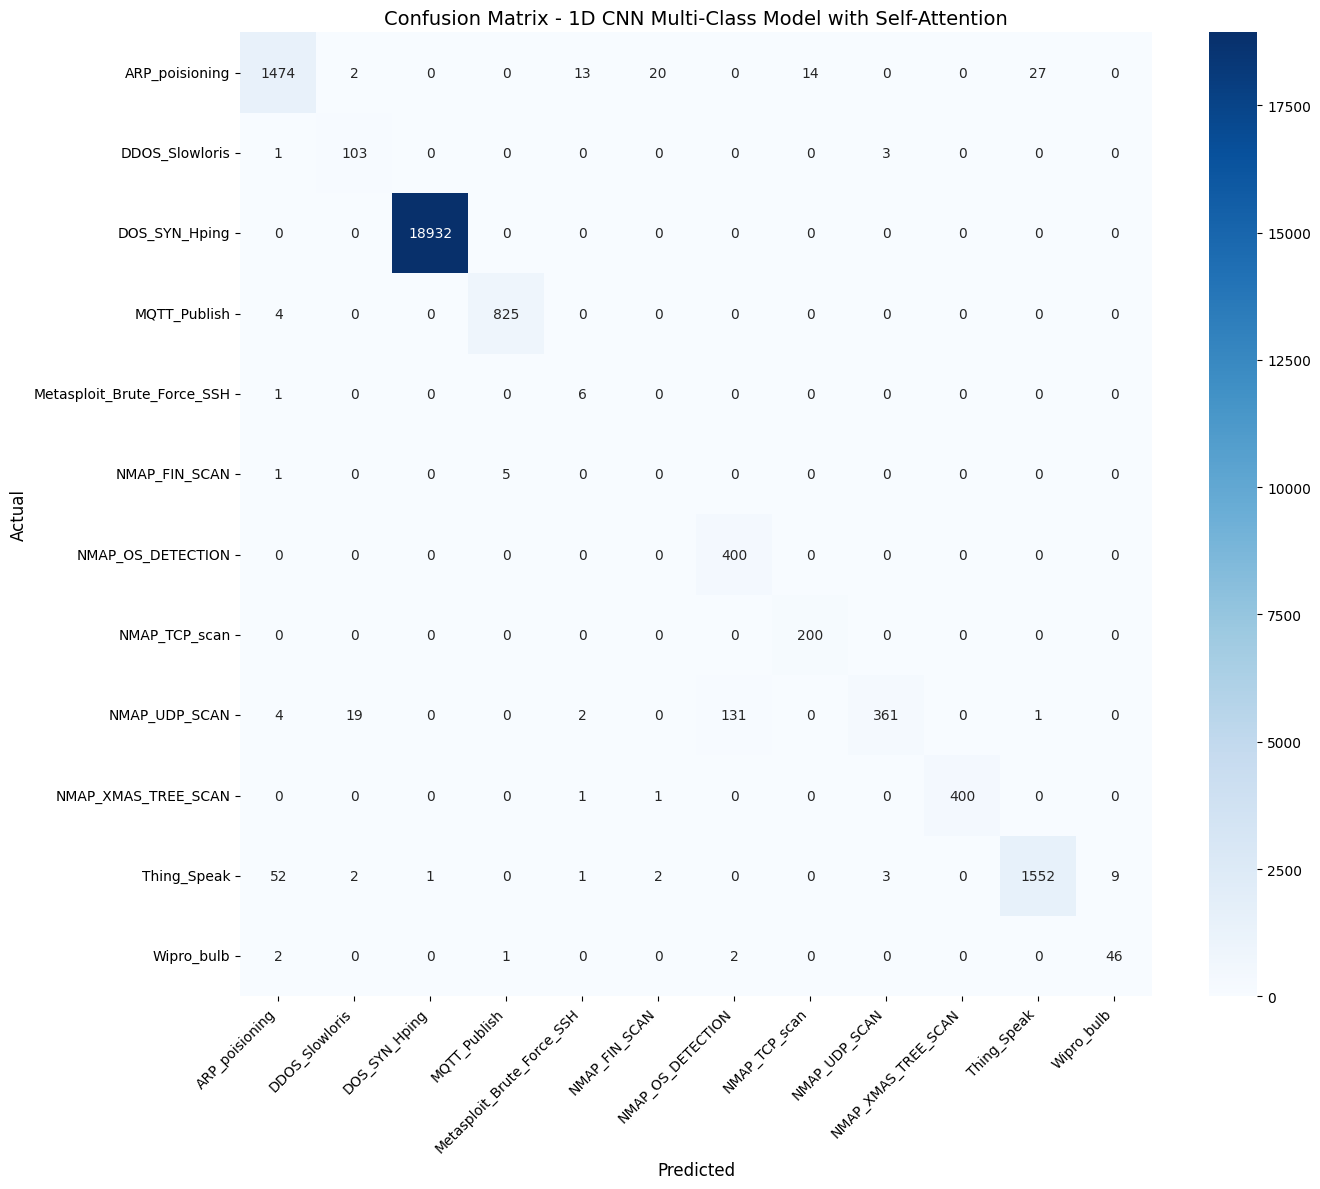

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Confusion Matrix - 1D CNN Multi-Class Model with Self-Attention", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusionmatrices/1dcnn_attn_multi.png", dpi=600, bbox_inches='tight')
plt.show()


In [ ]:
torch.save(model.state_dict(), "models/1dcnn_multiclass_attn.pth")
print("Model saved to models/1dcnn_multiclass_attn.pth")


Model saved to models/1dcnn_multiclass_attn.pth
